## Netflix Content-Based Recommendation System

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
#Load Dataset

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
#Basic Information

print("Dataset shape:", df.shape)
df.info()

Dataset shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [30]:
#Data Cleaning

netflix = df.copy()

netflix["director"] = netflix["director"].fillna("")
netflix["cast"] = netflix["cast"].fillna("")
netflix["country"] = netflix["country"].fillna("")
netflix["listed_in"] = netflix["listed_in"].fillna("")
netflix["description"] = netflix["description"].fillna("")
netflix["rating"] = netflix["rating"].fillna("Unknown")

netflix["date_added"] = pd.to_datetime(netflix["date_added"], errors="coerce")

most_common_date = netflix["date_added"].mode()[0]
netflix["date_added"] = netflix["date_added"].fillna(most_common_date)

netflix["year_added"] = netflix["date_added"].dt.year

netflix = netflix.drop_duplicates()

netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
dtype: int64

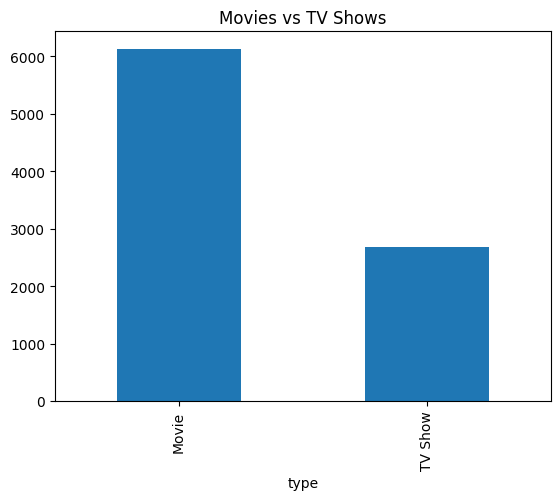

In [32]:
#EDA

netflix["type"].value_counts().plot(kind="bar", title="Movies vs TV Shows")
plt.show()

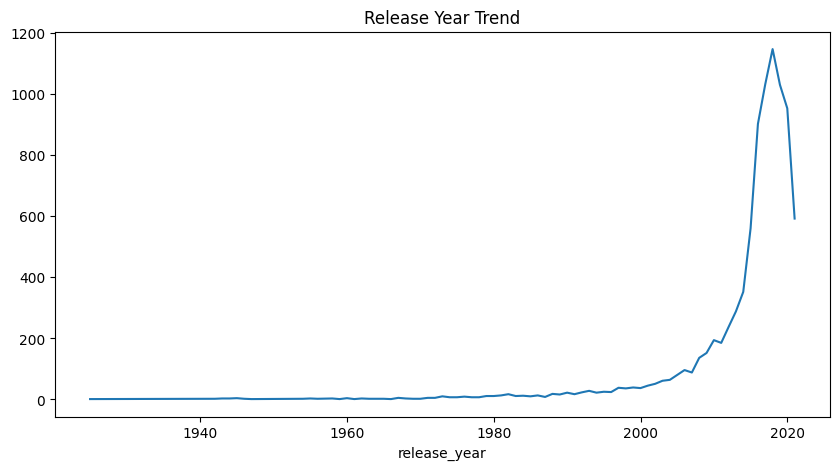

In [34]:
#Release year trend

netflix["release_year"].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Release Year Trend")
plt.show()

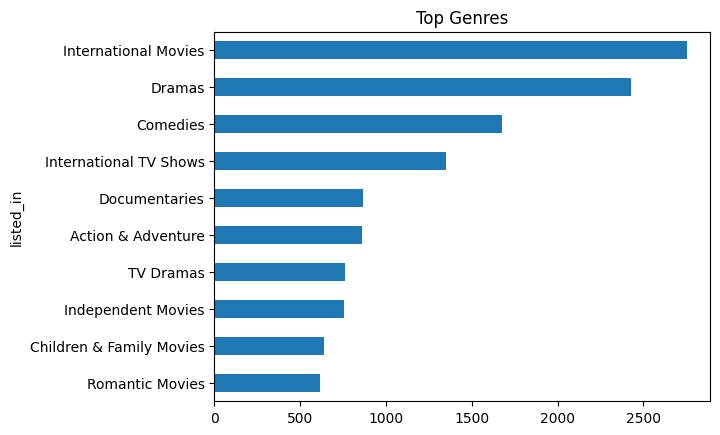

In [22]:
#Top genres

genres = netflix["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(10)

top_genres.sort_values().plot(kind="barh", title="Top Genres")
plt.show()

In [38]:
#Feature Engineering

netflix["combined_features"] = (
    netflix["listed_in"] + " " +
    netflix["description"] + " " +
    netflix["cast"] + " " +
    netflix["director"] + " " +
    netflix["country"]
)

netflix[["title", "combined_features"]].head()

,title,combined_features
0,Dick Johnson Is Dead,Documentaries As her father nears the end of h...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Feuds, flirtations and ..."
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


In [40]:
#TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(netflix["combined_features"])

print(tfidf_matrix.shape)

(8807, 5000)


In [42]:
#Cosine Similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [44]:
#Title Index Mapping

netflix = netflix.reset_index(drop=True)

title_indices = pd.Series(
    netflix.index,
    index=netflix["title"].str.lower()
).drop_duplicates()

In [46]:
#Recommendation Function（核心）

def recommend_titles(title, top_n=10):
    title = title.lower()
    
    if title not in title_indices:
        return f"'{title}' not found."
    
    idx = title_indices[title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    
    indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    
    result = netflix.loc[
        indices,
        ["title", "type", "listed_in", "release_year"]
    ].copy()
    
    result["similarity_score"] = scores
    
    return result

In [48]:
#Test

recommend_titles("Stranger Things")

,title,type,listed_in,release_year,similarity_score
5200,Beyond Stranger Things,TV Show,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV...",2017,0.506208
1240,Safe Haven,Movie,"Dramas, Romantic Movies",2013,0.204719
6703,Equilibrium,Movie,"Action & Adventure, Dramas, Sci-Fi & Fantasy",2002,0.198306
1487,Sakho & Mangane,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2019,0.190072
2600,Good Witch,TV Show,"TV Dramas, TV Sci-Fi & Fantasy",2019,0.188896
2303,Warrior Nun,TV Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",2020,0.185839
2200,Tread,Movie,Documentaries,2019,0.178899
4809,Kiss Me First,TV Show,"British TV Shows, Crime TV Shows, Internationa...",2018,0.176270
6167,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",2018,0.175995
241,Manifest,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",2021,0.172456


In [50]:
recommend_titles("The Crown")

,title,type,listed_in,release_year,similarity_score
4296,Flowers,TV Show,"British TV Shows, International TV Shows, TV C...",2018,0.215010
7333,London Spy,TV Show,"British TV Shows, Crime TV Shows, Internationa...",2015,0.200293
1998,Call the Midwife,TV Show,"British TV Shows, International TV Shows, TV D...",2020,0.197750
789,Downton Abbey,TV Show,"British TV Shows, International TV Shows, TV D...",2015,0.190200
5032,The Frankenstein Chronicles,TV Show,"British TV Shows, Crime TV Shows, Internationa...",2017,0.189225
6971,Hinterland,TV Show,"British TV Shows, Crime TV Shows, Internationa...",2016,0.186678
8476,The Real Football Factories,TV Show,"British TV Shows, Docuseries, International TV...",2006,0.183422
4166,Black Earth Rising,TV Show,"British TV Shows, International TV Shows, TV D...",2018,0.182973
7538,My Hotter Half,TV Show,"British TV Shows, International TV Shows, Real...",2017,0.177114
2080,Thomas and Friends,TV Show,"British TV Shows, Classic & Cult TV, Kids' TV",2020,0.176331


In [54]:
#Search Function

def search_title(keyword):
    keyword = keyword.lower()
    return netflix[
        netflix["title"].str.lower().str.contains(keyword, na=False)
    ][["title", "type", "release_year"]].head(10)

In [56]:
search_title("dark")

,title,type,release_year
28,Dark Skies,Movie,2013
493,RESIDENT EVIL: Infinite Darkness,TV Show,2021
738,Trese After Dark,Movie,2021
919,The Sons of Sam: A Descent into Darkness,TV Show,2021
949,The Darkest Hour,Movie,2011
1039,Dark City Beneath the Beat,Movie,2020
2027,Satria Heroes: Revenge of the Darkness,Movie,2017
2104,Dark Forces,Movie,2020
2149,We Summon the Darkness,Movie,2020
2229,In The Dark,TV Show,2020


In [58]:
#Flexible Recommendation

def recommend_titles_flexible(title, top_n=10):
    title_lower = title.lower()
    
    if title_lower not in title_indices:
        print("Not found. Try these:")
        return search_title(title)
    
    return recommend_titles(title, top_n)

In [60]:
recommend_titles_flexible("dark")

,title,type,listed_in,release_year,similarity_score
1951,A Perfect Crime,TV Show,"Crime TV Shows, Docuseries, International TV S...",2020,0.242038
260,The Defeated,TV Show,"Crime TV Shows, International TV Shows, TV Dramas",2020,0.235582
1335,The Sinner,TV Show,"Crime TV Shows, TV Dramas, TV Mysteries",2020,0.218505
3772,Alles ist gut,Movie,"Dramas, International Movies",2019,0.215552
4508,Stunt Science,TV Show,"British TV Shows, International TV Shows, Real...",2018,0.201902
8002,Sherlock,TV Show,"British TV Shows, Crime TV Shows, Internationa...",2017,0.193095
2874,Altered Carbon,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",2020,0.191030
2101,Baewatch: Parental Guidance,TV Show,"British TV Shows, Reality TV, Romantic TV Shows",2019,0.188987
6714,Everyday Miracles,TV Show,"British TV Shows, Docuseries, International TV...",2014,0.188022
6836,Gentlemen and Gangsters,TV Show,"Crime TV Shows, International TV Shows, Romant...",2016,0.187646


In [62]:
#Save Example

result = recommend_titles("Stranger Things", top_n=5)

result.to_csv("recommendations.csv", index=False)

print("Saved.")

Saved.


In [64]:
print("""
This project built a content-based recommendation system using Netflix title metadata.
The model combines genre, description, cast, director, and country information into text features.
TF-IDF was used to transform text into numerical vectors, and cosine similarity was used to find similar titles.
The system can recommend Top-N similar movies or TV shows based on a selected Netflix title.
""")


This project built a content-based recommendation system using Netflix title metadata.
The model combines genre, description, cast, director, and country information into text features.
TF-IDF was used to transform text into numerical vectors, and cosine similarity was used to find similar titles.
The system can recommend Top-N similar movies or TV shows based on a selected Netflix title.

